In [60]:
# IMPORT
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.base import clone
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import random

from jmetal.operator.mutation import PolynomialMutation
from jmetal.operator.crossover import SBXCrossover
from jmetal.algorithm.multiobjective import NSGAII, SPEA2
from jmetal.core.solution import FloatSolution
from jmetal.util.termination_criterion import StoppingByEvaluations
from jmetal.util.solution import get_non_dominated_solutions
from jmetal.core.problem import Problem


In [61]:
# Lecture des fichiers
df_diabetes = pd.read_csv("diabetes.csv")
df_yeast     = pd.read_csv("yeast.csv")

print("Diabetes shape:", df_diabetes.shape)
print("Yeast shape:", df_yeast.shape)


Diabetes shape: (768, 9)
Yeast shape: (1484, 9)


In [62]:
def evaluate_individual(X, y_true, chromosomes):
    """
    Transforme un chromosome [bi1, bs1, bi2, bs2, ...] en une règle,
    fait la prédiction sur X, et renvoie (precision, recall).
    (F1 est gardée pour analyse, pas pour le front de Pareto.)
    """
    n_attributes = X.shape[1]
    y_pred = []

    for instance in X:
        is_positive = True
        for i in range(n_attributes):
            bi = chromosomes[2 * i]
            bs = chromosomes[2 * i + 1]
            # attribut actif si bi <= bs
            if bi <= bs:
                if not (bi <= instance[i] <= bs):
                    is_positive = False
                    break
        y_pred.append(1 if is_positive else 0)

    y_pred = np.array(y_pred)

    if sum(y_pred) == 0:
        precision = 0.0
        recall    = 0.0
        f1        = 0.0
    else:
        precision = precision_score(y_true, y_pred, zero_division=0)
        recall    = recall_score(y_true, y_pred, zero_division=0)
        f1        = f1_score(y_true, y_pred, average='binary', zero_division=0)

    return precision, recall, f1  # tuple (precision, recall, f1)


In [63]:
class PartialClassifProblemMO(Problem):
    def __init__(self, X_train, y_train, X_test, y_test):
        super().__init__()
        self.X_train = np.array(X_train, dtype=float)
        self.y_train = np.array(y_train, dtype=int)
        self.X_test  = np.array(X_test,  dtype=float)
        self.y_test  = np.array(y_test,  dtype=int)

        self.n_attributes = self.X_train.shape[1]

        # Bornes de chaque attribut
        mins = X_train.min(axis=0)
        maxs = X_train.max(axis=0)
        self.lower_bound = []
        self.upper_bound = []

        for i in range(self.n_attributes):
            self.lower_bound.extend([mins[i], mins[i]])
            self.upper_bound.extend([maxs[i], maxs[i]])

    def number_of_variables(self) -> int:
        return 2 * self.n_attributes

    def number_of_objectives(self) -> int:
        return 2  # precision, recall

    def number_of_constraints(self) -> int:
        return 0

    def evaluate(self, solution: FloatSolution) -> FloatSolution:
        # Évaluer sur X_train
        prec, rec, _ = evaluate_individual(
            X=self.X_train,
            y_true=self.y_train,
            chromosomes=solution.variables
        )

        solution.objectives[0] = -prec
        solution.objectives[1] = -rec

        return solution

    def create_solution(self) -> FloatSolution:
        solution = FloatSolution(
            lower_bound=self.lower_bound,
            upper_bound=self.upper_bound,
            number_of_objectives=self.number_of_objectives(),
            number_of_constraints=self.number_of_constraints()
        )
        solution.variables = [
            random.uniform(self.lower_bound[i], self.upper_bound[i])
            for i in range(self.number_of_variables())
        ]
        return solution

    def name(self) -> str:
        return "PartialClassifProblemMO"

    def get_rule(self, solution: FloatSolution, feature_names=None) -> dict:
        """
        Renvoie une règle "lisible" de la forme :
        { "attribute_name": [min, max] } ou None si l'attribut est inactif.
        """
        n_attributes = self.n_attributes
        rule = {}
        if feature_names is None:
            feature_names = [f"X{i}" for i in range(n_attributes)]

        for i in range(n_attributes):
            bi = solution.variables[2 * i]
            bs = solution.variables[2 * i + 1]
            if bi <= bs:
                rule[feature_names[i]] = [bi, bs]
            else:
                rule[feature_names[i]] = None  # attribut inactif

        return rule

    def evaluate_test(self, solution: FloatSolution):
        """
        Évalue une solution sur le test (X_test, y_test) et renvoie:
        precision, recall, f1, accuracy
        """
        # Adapter chromosomes à X_test
        y_pred = []

        for instance in self.X_test:
            is_positive = True
            for i in range(self.n_attributes):
                bi = solution.variables[2 * i]
                bs = solution.variables[2 * i + 1]
                if bi <= bs:
                    if not (bi <= instance[i] <= bs):
                        is_positive = False
                        break
            y_pred.append(1 if is_positive else 0)

        y_pred = np.array(y_pred)

        if sum(y_pred) == 0:
            precision = 0.0
            recall    = 0.0
            f1        = 0.0
            accuracy  = 0.0
        else:
            precision = precision_score(self.y_test, y_pred, zero_division=0)
            recall    = recall_score(self.y_test, y_pred, zero_division=0)
            f1        = f1_score(self.y_test, y_pred, average='binary', zero_division=0)
            accuracy  = accuracy_score(self.y_test, y_pred)

        return precision, recall, f1, accuracy


In [64]:
# Nettoyage des zéros impossibles (diabète)
zero_impossible_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df_diabetes[zero_impossible_cols] = df_diabetes[zero_impossible_cols].replace(0, np.nan)
df_diabetes.fillna(df_diabetes.median(numeric_only=True), inplace=True)

# X, y pour le diabète (classification binaire déjà existante : 0/1)
X_diabetes = df_diabetes.drop('Outcome', axis=1)  # 8 attributs
y_diabetes = df_diabetes['Outcome']                # 0 ou 1

# Split train / test
X_train_diabetes, X_test_diabetes, y_train_diabetes, y_test_diabetes = train_test_split(
    X_diabetes,
    y_diabetes,
    test_size=0.2,
    random_state=42,
    stratify=y_diabetes
)

print("X_train_diabetes shape:", X_train_diabetes.shape)
print("y_train_diabetes shape:", y_train_diabetes.shape)
print("Classes dans y_train : 0 =", (y_train_diabetes == 0).sum(), ", 1 =", (y_train_diabetes == 1).sum())


X_train_diabetes shape: (614, 8)
y_train_diabetes shape: (614,)
Classes dans y_train : 0 = 400 , 1 = 214


In [65]:
# Standardisation pour SVM
scaler = StandardScaler()
X_train_diabetes_scaled = scaler.fit_transform(X_train_diabetes)
X_test_diabetes_scaled  = scaler.transform(X_test_diabetes)

# Modèles
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    random_state=42
)

svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    probability=True,
    random_state=42
)

c45_model = DecisionTreeClassifier(
    criterion='entropy',
    splitter='best',
    max_depth=None,
    min_samples_split=2,
    random_state=42
)

# Configurations
model_configs = {
    "Random Forest": (rf_model, X_train_diabetes, X_test_diabetes),
    "SVM":         (svm_model, X_train_diabetes_scaled, X_test_diabetes_scaled),
    "C4.5":        (c45_model, X_train_diabetes, X_test_diabetes),
}

# Évaluation
results_diabetes = {}

for name, (model, X_tr, X_te) in model_configs.items():
    model.fit(X_tr, y_train_diabetes)

    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]  # proba de la classe 1

    # Métriques
    acc = accuracy_score(y_test_diabetes, y_pred)
    cv_scores = cross_val_score(model, X_tr, y_train_diabetes, cv=5, scoring='accuracy')

    results_diabetes[name] = {
        "Accuracy":   acc,
        "ROC AUC":    roc_auc_score(y_test_diabetes, y_prob),
        "CV Mean":    cv_scores.mean(),
        "CV Std":     cv_scores.std(),
        "y_pred":     y_pred,
        "y_prob":     y_prob,
        "model":      model,
    }

# Affichage des résultats
for name, scores in results_diabetes.items():
    print(f"{name:<12} | Acc: {scores['Accuracy']:.3f} | ROC AUC: {scores['ROC AUC']:.3f} | CV Mean: {scores['CV Mean']:.3f} ± {scores['CV Std']:.3f}")


Random Forest | Acc: 0.779 | ROC AUC: 0.819 | CV Mean: 0.772 ± 0.033
SVM          | Acc: 0.740 | ROC AUC: 0.796 | CV Mean: 0.769 ± 0.018
C4.5         | Acc: 0.675 | ROC AUC: 0.639 | CV Mean: 0.694 ± 0.036


In [66]:
def run_algorithm(algorithm_class, problem, population_size, max_evaluations, crossover_prob=0.9, mutation_prob=None):
    n_vars = problem.number_of_variables()
    if mutation_prob is None:
        mutation_prob = 1.0 / n_vars

    crossover = SBXCrossover(probability=crossover_prob, distribution_index=20)
    mutation = PolynomialMutation(probability=mutation_prob, distribution_index=20)

    # gestion de la compatibilité version jmetalpy
    try:
        termination = StoppingByEvaluations(max_evaluations=max_evaluations)
    except TypeError:
        termination = StoppingByEvaluations(max=max_evaluations)

    algorithm = algorithm_class(
        problem=problem,
        population_size=population_size,
        offspring_population_size=population_size,
        mutation=mutation,
        crossover=crossover,
        termination_criterion=termination
    )

    print(f"Running {algorithm.get_name()} — {max_evaluations} evaluations...")
    algorithm.run()

    try:
        raw_results = algorithm.result()
    except AttributeError:
        raw_results = algorithm.get_result()

    pareto_front = get_non_dominated_solutions(raw_results)
    print(f"Done. Pareto front size: {len(pareto_front)}")
    return pareto_front, algorithm


In [67]:
# Pour pima‑diabète
y_train_bin = (y_train_diabetes == 1).astype(int)
y_test_bin  = (y_test_diabetes  == 1).astype(int)

problem = PartialClassifProblemMO(
    X_train=X_train_diabetes.values,
    y_train=y_train_bin,
    X_test=X_test_diabetes.values,
    y_test=y_test_bin
)

# Lancer NSGAII via run_algorithm
pareto_front, algo = run_algorithm(
    algorithm_class=NSGAII,
    problem=problem,
    population_size=50,
    max_evaluations=5000
)

# Prendre une solution du front (ex: la meilleure en F1)
if pareto_front:
    best_solution = pareto_front[0]   # ou sélection via HV / F1
    rule = problem.get_rule(best_solution, feature_names=X_train_diabetes.columns.tolist())
    print("Règle trouvée :", rule)

    # évaluer sur le test
    prec, rec, f1, acc = problem.evaluate_test(best_solution)
    print(f"Test: prec={prec:.3f}, rec={rec:.3f}, f1={f1:.3f}, acc={acc:.3f}")


[2026-03-24 03:46:34,389] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-24 03:46:34,390] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-03-24 03:46:34,456] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-24 03:46:34,457] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met


Running NSGAII — 5000 evaluations...


[2026-03-24 03:46:46,550] [jmetal.core.algorithm] [DEBUG] Finished!


Done. Pareto front size: 41
Règle trouvée : {'Pregnancies': None, 'Glucose': None, 'BloodPressure': None, 'SkinThickness': None, 'Insulin': None, 'BMI': None, 'DiabetesPedigreeFunction': None, 'Age': None}
Test: prec=0.351, rec=1.000, f1=0.519, acc=0.351


In [68]:
def compute_hv_from_solutions(solutions, ref_point=None):
    """
    Calcule l'hypervolume SANS jMetalPy (version robuste)
    """
    # Extraire les objectifs (-precision, -recall → precision, recall)
    objectives = np.array([[-sol.objectives[0], -sol.objectives[1]] for sol in solutions])
    
    if ref_point is None:
        ref_point = np.max(objectives, axis=0) + 0.1
    
    # ALGO SIMPLE 2D Hypervolume (ne dépend que de numpy)
    def hypervolume_2d(points, ref):
        points = points[points[:, 0] <= ref[0]]
        points = points[points[:, 1] <= ref[1]]
        if len(points) == 0:
            return 0.0
        
        # Trier par précision décroissante
        points = points[np.argsort(-points[:, 0])]
        
        hv = 0.0
        prev_prec = ref[0]
        
        for prec, rec in points:
            hv += (prev_prec - prec) * (rec - 0.0)  # 0 car recall >= 0
            prev_prec = prec
            
        return hv
    
    return hypervolume_2d(objectives, ref_point)

# RUN

In [69]:
N_RUNS = 20
MAX_EVALUATIONS = 100
POP_SIZES = [20, 50, 100]

results_mo = {ds_name: {"NSGAII": {}, "SPEA2": {}} for ds_name in datasets}

for dataset_name, data_dict in datasets.items():
    print(f"\n=== JEUX DE DONNÉES : {dataset_name} ===")

    X_tr = data_dict["X_train"]
    y_tr = data_dict["y_train"]
    X_te = data_dict["X_test"]
    y_te = data_dict["y_test"]

    for algo_name, algo_class in [("NSGAII", NSGAII), ("SPEA2", SPEA2)]:
        print(f"\n{algo_name} | {dataset_name}")

        results_mo[dataset_name][algo_name] = {}

        for pop_size in POP_SIZES:
            print(f"  Population size = {pop_size} (20 runs)")

            runs = []

            for run_idx in range(N_RUNS):
                problem = PartialClassifProblemMO(
                    X_train=X_tr,
                    y_train=y_tr,
                    X_test=X_te,
                    y_test=y_te
                )

                pareto_front_train, _ = run_algorithm(
                    algorithm_class=algo_class,
                    problem=problem,
                    population_size=pop_size,
                    max_evaluations=MAX_EVALUATIONS,
                    crossover_prob=0.9
                )

                # 1. Extraire (precision, recall) sur le train
                precisions = []
                recalls = []

                for sol in pareto_front_train:
                    # JMetalPy stocke : -precision, -recall
                    prec = -sol.objectives[0]
                    rec  = -sol.objectives[1]
                    precisions.append(prec)
                    recalls.append(rec)

                # 2. Calculer HV sur le front de Pareto (train)
                hv_train = compute_hv_from_solutions(pareto_front_train)

                # 3. Trouver la solution avec le meilleur F1
                best_f1 = None
                best_f1_prec = None
                best_f1_rec = None
                best_f1_solution = None
                
                for sol in pareto_front_train:
                    prec, rec, f1 = evaluate_individual(
                        X=X_tr,
                        y_true=y_tr,
                        chromosomes=sol.variables
                    )

                    if best_f1 is None or f1 > best_f1:
                        best_f1 = f1
                        best_f1_prec = prec
                        best_f1_rec = rec
                        best_f1_solution = sol

                # 4. Stocker tout dans le dictionnaire du run
                runs.append({
                    "run_idx": run_idx,
                    "pop_size": pop_size,
                    "pareto_train": pareto_front_train,
                    "precisions_train": precisions,
                    "recalls_train": recalls,
                    "hv_train": hv_train,
                    "best_f1_solution": best_f1_solution,
                    "best_f1": best_f1 if best_f1 is not None else 0.0,
                    "best_f1_prec": best_f1_prec if best_f1_prec is not None else 0.0,
                    "best_f1_rec": best_f1_rec if best_f1_rec is not None else 0.0,
                })

            results_mo[dataset_name][algo_name][pop_size] = runs

print("5.3 Stockage des résultats terminé.")


[2026-03-24 03:46:46,569] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-24 03:46:46,569] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-03-24 03:46:46,595] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-24 03:46:46,596] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-24 03:46:46,750] [jmetal.core.algorithm] [DEBUG] Finished!



=== JEUX DE DONNÉES : Pima Diabetes ===

NSGAII | Pima Diabetes
  Population size = 20 (20 runs)
Running NSGAII — 100 evaluations...
Done. Pareto front size: 9


[2026-03-24 03:46:46,778] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-24 03:46:46,778] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-03-24 03:46:46,801] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-24 03:46:46,801] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-24 03:46:46,952] [jmetal.core.algorithm] [DEBUG] Finished!


Running NSGAII — 100 evaluations...
Done. Pareto front size: 11


[2026-03-24 03:46:46,985] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-24 03:46:46,985] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-03-24 03:46:47,016] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-24 03:46:47,016] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-24 03:46:47,178] [jmetal.core.algorithm] [DEBUG] Finished!


...

Done. Pareto front size: 9
Running SPEA2 — 100 evaluations...
Done. Pareto front size: 8
Running SPEA2 — 100 evaluations...


[2026-03-24 03:47:11,448] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-24 03:47:11,449] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-24 03:47:11,449] [jmetal.core.algorithm] [DEBUG] Finished!
[2026-03-24 03:47:11,470] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-24 03:47:11,471] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-03-24 03:47:11,588] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-24 03:47:11,589] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-24 03:47:11,589] [jmetal.core.algorithm] [DEBUG] Finished!
[2026-03-24 03:47:11,607] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-24 03:47:11,608] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...


Done. Pareto front size: 7
Running SPEA2 — 100 evaluations...
Done. Pareto front size: 6
Running SPEA2 — 100 evaluations...


[2026-03-24 03:47:11,709] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-24 03:47:11,710] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-24 03:47:11,710] [jmetal.core.algorithm] [DEBUG] Finished!


Done. Pareto front size: 6
5.3 Stockage des résultats terminé.


# DONE RUN

In [70]:
# 1. Récupérer datasets, algos, tailles
summary = []

for dataset_name in results_mo:
    for algo_name in results_mo[dataset_name]:
        for pop_size in results_mo[dataset_name][algo_name]:
            runs = results_mo[dataset_name][algo_name][pop_size]

            hvs = []
            precisions = []
            recalls = []

            for r in runs:
                hvs.append(r["hv_train"])

                # Pour simplifier : on prend la moyenne de tous les points du front
                # ou tu peux garder la moyenne de precision/recall sur le front
                if len(r["precisions_train"]) > 0:
                    precisions.append(np.mean(r["precisions_train"]))
                    recalls.append(np.mean(r["recalls_train"]))

            if hvs:
                row = {
                    "dataset": dataset_name,
                    "algorithm": algo_name,
                    "pop_size": pop_size,
                    "hv_mean": np.mean(hvs),
                    "hv_std": np.std(hvs),
                    "precision_mean": np.mean(precisions),
                    "precision_std": np.mean(precisions),
                    "recall_mean": np.mean(recalls),
                    "recall_std": np.std(recalls),
                    "n_runs": len(hvs)
                }
                summary.append(row)

df_summary = pd.DataFrame(summary)
print(df_summary)


         dataset algorithm  pop_size   hv_mean    hv_std  precision_mean  \
0  Pima Diabetes    NSGAII        20  0.208636  0.087324        0.652472   
1  Pima Diabetes    NSGAII        50  0.160699  0.054719        0.659112   
2  Pima Diabetes    NSGAII       100  0.194016  0.075186        0.659419   
3  Pima Diabetes     SPEA2        20  0.204371  0.070960        0.641622   
4  Pima Diabetes     SPEA2        50  0.182078  0.079892        0.656151   
5  Pima Diabetes     SPEA2       100  0.188311  0.051802        0.643547   

   precision_std  recall_mean  recall_std  n_runs  
0       0.652472     0.338386    0.104056      20  
1       0.659112     0.276425    0.094264      20  
2       0.659419     0.301434    0.088715      20  
3       0.641622     0.341289    0.111388      20  
4       0.656151     0.295335    0.096171      20  
5       0.643547     0.319789    0.089639      20  


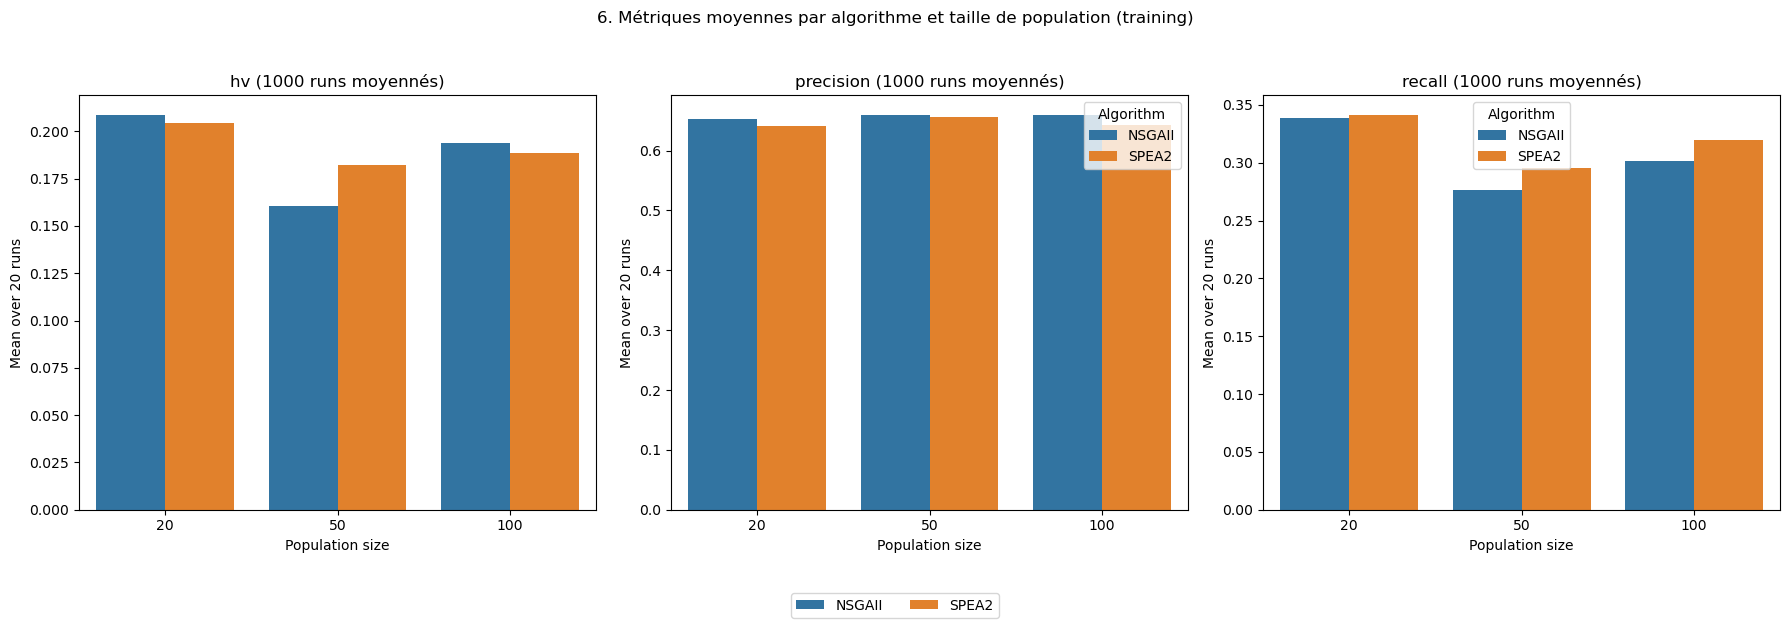

In [71]:
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

handles = []  # pour légende unique
labels = []

for i, metric in enumerate(["hv_mean", "precision_mean", "recall_mean"]):
    # Créer un DataFrame long pour seaborn
    df_long = []

    for dataset_name in df_summary["dataset"].unique():
        for algo_name in df_summary["algorithm"].unique():
            for pop_size in df_summary["pop_size"].unique():
                mask = (df_summary["dataset"] == dataset_name) & \
                       (df_summary["algorithm"] == algo_name) & \
                       (df_summary["pop_size"] == pop_size)

                if mask.any():
                    val = df_summary.loc[mask, metric].values[0]
                    df_long.append({
                        "dataset": dataset_name,
                        "algorithm": algo_name,
                        "pop_size": pop_size,
                        "value": val
                    })

    df_long = pd.DataFrame(df_long)

    # On fait un boxplot par algo + taille de population
    # ici par exemple on boxplot par pop_size dans chaque algo
    sns.barplot(
        data=df_long,
        x="pop_size",
        y="value",
        hue="algorithm",
        ax=axs[i]
    )

    axs[i].set_title(f"{metric.replace('_mean', '')} (1000 runs moyennés)")
    axs[i].set_ylabel("Mean over 20 runs")
    axs[i].set_xlabel("Population size")
    axs[i].legend(title="Algorithm")

    # Garder les légendes des premiers (pour éviter redondance)
    if i == 0:
        handles += axs[i].get_legend().legendHandles
        labels += [t.get_text() for t in axs[i].get_legend().get_texts()]
        axs[i].get_legend().remove()

# Légende globale
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.02), ncol=2)

plt.suptitle("6. Métriques moyennes par algorithme et taille de population (training)")
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()


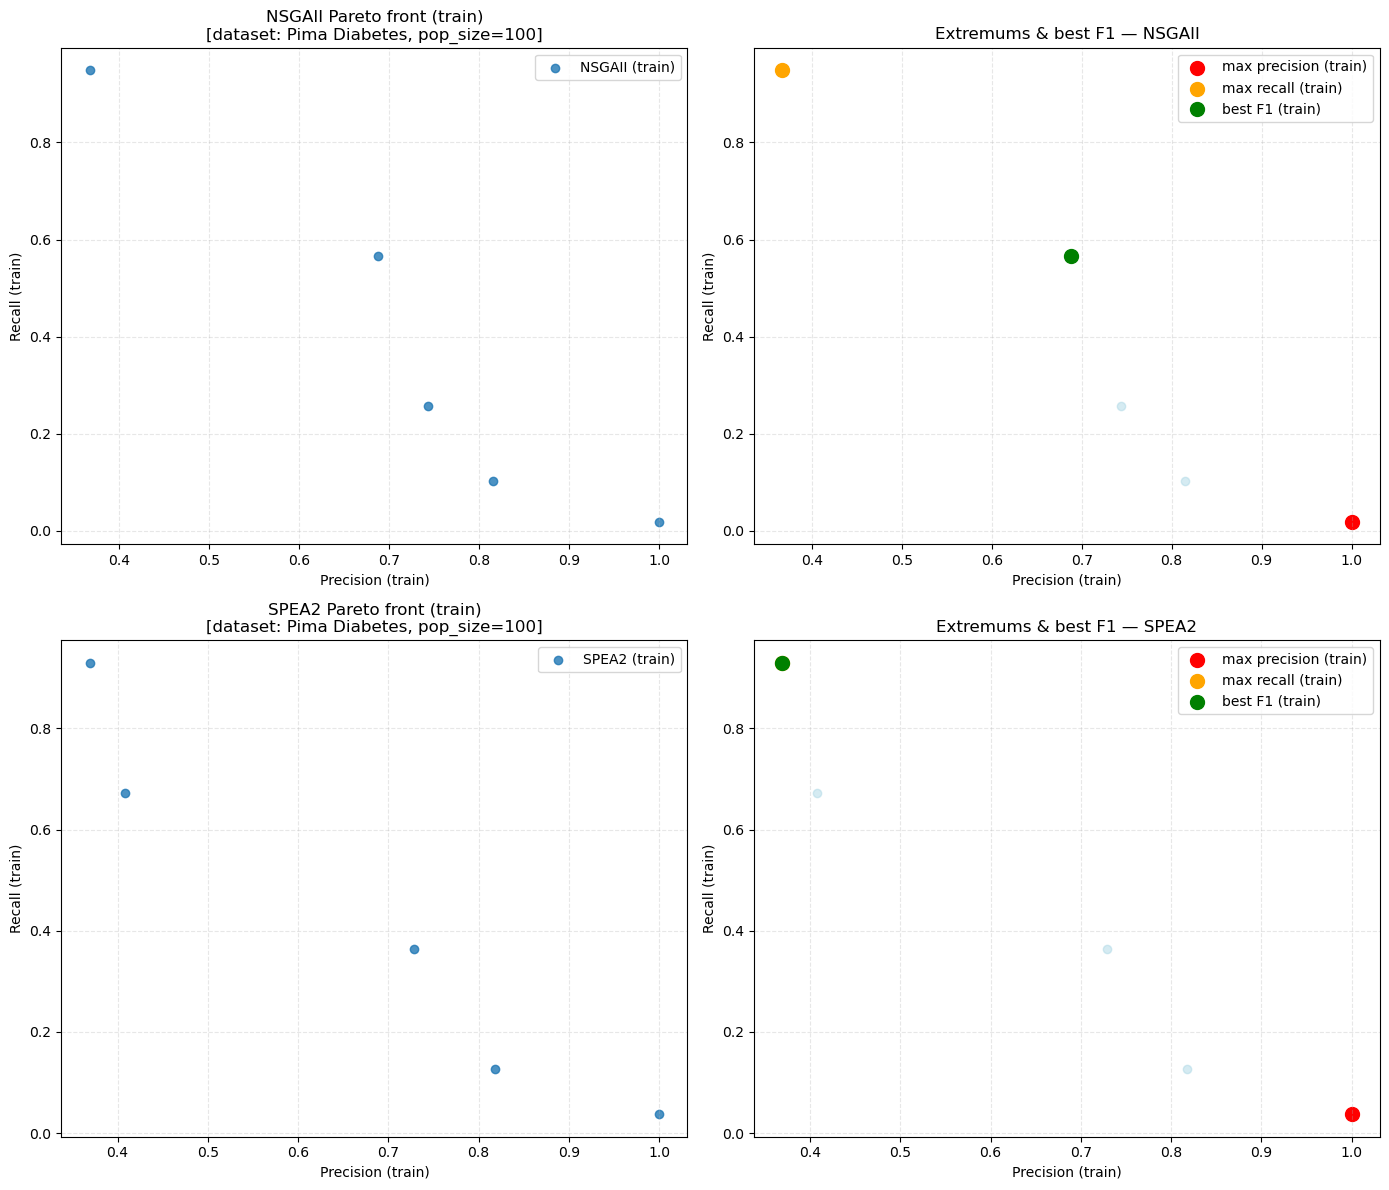

In [72]:
def plot_representative_fronts(
    results_mo,
    dataset_name,
    X_train,
    y_train,
    best_pop_size=100
):
    """
    Dessine 1 front représentatif par algo (NSGAII, SPEA2) pour un dataset donné.
    """
    fig, axs = plt.subplots(2, 2, figsize=(14, 12))
    row_idx = 0

    for algo_name in ["NSGAII", "SPEA2"]:
        if algo_name not in results_mo[dataset_name]:
            row_idx += 1
            continue

        ax = axs[row_idx, 0]
        ax2 = axs[row_idx, 1]

        runs = results_mo[dataset_name][algo_name][best_pop_size]

        # Choix du run avec le meilleur HV
        best_run = max(runs, key=lambda r: r["hv_train"])
        front = best_run["pareto_train"]

        # Extraire precision/recall (stockés en négatif)
        precisions = [-sol.objectives[0] for sol in front]
        recalls    = [-sol.objectives[1] for sol in front]

        # 1. Front de Pareto
        ax.scatter(precisions, recalls, alpha=0.8, label=f"{algo_name} (train)")
        ax.set_title(f"{algo_name} Pareto front (train)\n[dataset: {dataset_name}, pop_size={best_pop_size}]")
        ax.set_xlabel("Precision (train)")
        ax.set_ylabel("Recall (train)")
        ax.grid(True, linestyle="--", alpha=0.3)
        ax.legend()

        # 2. Identifier les extremités et best F1
        max_prec_idx = np.argmax(precisions)
        max_rec_idx  = np.argmax(recalls)

        # Calcul de F1 pour chaque point (nécessite X_train et y_train)
        fs = []
        for sol in front:
            prec, rec, f1 = evaluate_individual(
                X=X_train,
                y_true=y_train,
                chromosomes=sol.variables
            )
            fs.append(f1)

        best_f1_idx = np.argmax(fs)

        # 2 bis. Plot extremités + best F1
        ax2.scatter(precisions, recalls, c="lightblue", alpha=0.5)
        ax2.scatter(precisions[max_prec_idx], recalls[max_prec_idx], c="red", s=100, label="max precision (train)")
        ax2.scatter(precisions[max_rec_idx], recalls[max_rec_idx], c="orange", s=100, label="max recall (train)")
        ax2.scatter(precisions[best_f1_idx], recalls[best_f1_idx], c="green", s=100, label="best F1 (train)")

        ax2.set_title(f"Extremums & best F1 — {algo_name}")
        ax2.set_xlabel("Precision (train)")
        ax2.set_ylabel("Recall (train)")
        ax2.legend()
        ax2.grid(True, linestyle="--", alpha=0.3)

        row_idx += 1

    plt.tight_layout()
    plt.show()


# Exemple d’appel pour pima_diabetes
X_train = X_train_diabetes.values
y_train = (y_train_diabetes == 1).astype(int)

plot_representative_fronts(
    results_mo,
    dataset_name="Pima Diabetes",
    X_train=X_train,
    y_train=y_train,
    best_pop_size=100
)


In [73]:
# 8.1. Compléter les métriques sklearn (train + test)
sklearn_results_complete = {}

for name, (model, X_tr, X_te) in model_configs.items():
    # Assurer que le modèle est bien fitté
    model.fit(X_tr, y_train_diabetes)
    
    # Prédictions train
    y_pred_train = model.predict(X_tr)
    y_prob_train = model.predict_proba(X_tr)[:, 1] if hasattr(model, 'predict_proba') else None
    
    # Prédictions test  
    y_pred_test = model.predict(X_te)
    y_prob_test = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else None
    
    # Métriques TRAIN
    prec_train = precision_score(y_train_diabetes, y_pred_train, zero_division=0)
    rec_train  = recall_score(y_train_diabetes, y_pred_train, zero_division=0)
    f1_train   = f1_score(y_train_diabetes, y_pred_train, zero_division=0)
    
    # Métriques TEST
    prec_test  = precision_score(y_test_diabetes, y_pred_test, zero_division=0)
    rec_test   = recall_score(y_test_diabetes, y_pred_test, zero_division=0)
    f1_test    = f1_score(y_test_diabetes, y_pred_test, zero_division=0)
    
    sklearn_results_complete[name] = {
        "prec_train": prec_train,
        "rec_train": rec_train,
        "f1_train": f1_train,
        "prec_test": prec_test,
        "rec_test": rec_test,
        "f1_test": f1_test,
        "model": model
    }
    
    print(f"{name:<12} | TRAIN: P={prec_train:.3f} R={rec_train:.3f} F1={f1_train:.3f}")
    print(f"{'':<12}   | TEST:  P={prec_test:.3f} R={rec_test:.3f} F1={f1_test:.3f}\n")

print("Métriques sklearn complètes stockées dans sklearn_results_complete")


Random Forest | TRAIN: P=1.000 R=1.000 F1=1.000
               | TEST:  P=0.727 R=0.593 F1=0.653

SVM          | TRAIN: P=0.837 R=0.673 F1=0.746
               | TEST:  P=0.652 R=0.556 F1=0.600

C4.5         | TRAIN: P=1.000 R=1.000 F1=1.000
               | TEST:  P=0.538 R=0.519 F1=0.528

Métriques sklearn complètes stockées dans sklearn_results_complete


In [74]:
# Tableau récapitulatif sklearn (TRAIN vs TEST)
df_sklearn = pd.DataFrame({
    "Algo": list(sklearn_results_complete.keys()),
    "Prec Train": [sklearn_results_complete[name]["prec_train"] for name in sklearn_results_complete],
    "Rec Train": [sklearn_results_complete[name]["rec_train"] for name in sklearn_results_complete],
    "F1 Train": [sklearn_results_complete[name]["f1_train"] for name in sklearn_results_complete],
    "Prec Test": [sklearn_results_complete[name]["prec_test"] for name in sklearn_results_complete],
    "Rec Test": [sklearn_results_complete[name]["rec_test"] for name in sklearn_results_complete],
    "F1 Test": [sklearn_results_complete[name]["f1_test"] for name in sklearn_results_complete]
}).round(3)

print("Tableau sklearn complet (TRAIN | TEST) :")
print(df_sklearn.to_string(index=False))


Tableau sklearn complet (TRAIN | TEST) :
         Algo  Prec Train  Rec Train  F1 Train  Prec Test  Rec Test  F1 Test
Random Forest       1.000      1.000     1.000      0.727     0.593    0.653
          SVM       0.837      0.673     0.746      0.652     0.556    0.600
         C4.5       1.000      1.000     1.000      0.538     0.519    0.528


In [75]:
# Structure commune pour comparaison avec AG MO
results_comparison = {
    "sklearn": sklearn_results_complete,
    "mo_algorithms": results_mo  # tes résultats NSGAII/SPEA2 déjà stockés
}

# Sauvegarde
import pickle
with open("results_comparison_pima.pkl", "wb") as f:
    pickle.dump(results_comparison, f)

print(" Résultats sklearn prêts pour la comparaison avec AG MO (partie 9)")


 Résultats sklearn prêts pour la comparaison avec AG MO (partie 9)


In [76]:
# 8.4. RÉCAPITULATIF FINAL : sklearn vs AG MO
def extract_best_mo_metrics(results_mo, dataset_name, pop_size=100, metric="f1"):
    """
    Pour un AG MO, extraire la MEILLEURE métrique sur TEST :
    - 'f1' : meilleure solution en F1 sur test
    - 'precision' : solution avec max precision sur test  
    - 'recall' : solution avec max recall sur test
    """
    best_metrics = {}
    
    for algo_name in ["NSGAII", "SPEA2"]:
        if algo_name not in results_mo[dataset_name] or pop_size not in results_mo[dataset_name][algo_name]:
            best_metrics[algo_name] = {"prec_test": "N/A", "rec_test": "N/A", "f1_test": "N/A", "hv_train": "N/A"}
            continue
            
        # Meilleur run en HV sur train
        runs = results_mo[dataset_name][algo_name][pop_size]
        best_run_idx = max(range(len(runs)), key=lambda i: runs[i]["hv_train"])
        best_run = runs[best_run_idx]
        
        # Tu dois avoir accès au problème pour évaluer sur test
        # On prend la solution avec le meilleur F1 sur train et on l'évalue sur test
        if "best_f1_solution" in best_run and best_run["best_f1_solution"] is not None:
            # Si tu as stocké evaluate_test dans ta classe PartialClassifProblemMO
            # sinon tu dois recréer le problème pour évaluer sur test
            sol = best_run["best_f1_solution"]
            
            # Recréer temporairement le problème pour évaluer sur test
            problem = PartialClassifProblemMO(
                X_train=X_train_diabetes.values,
                y_train=(y_train_diabetes == 1).astype(int),
                X_test=X_test_diabetes.values,
                y_test=(y_test_diabetes == 1).astype(int)
            )
            
            prec_test, rec_test, f1_test, _ = problem.evaluate_test(sol)
            
            best_metrics[algo_name] = {
                "prec_test": round(prec_test, 3),
                "rec_test": round(rec_test, 3), 
                "f1_test": round(f1_test, 3),
                "hv_train": round(best_run["hv_train"], 3)
            }
        else:
            best_metrics[algo_name] = {"prec_test": "N/A", "rec_test": "N/A", "f1_test": "N/A", "hv_train": round(best_run["hv_train"], 3)}
    
    return best_metrics

# Extraire les meilleures métriques MO
mo_metrics = extract_best_mo_metrics(results_mo, "Pima Diabetes", pop_size=100)

# Créer le tableau final
table_data = {
    "Métrique": ["Précision (test)", "Sensibilité (test)", "F1-mesure (test)", "Hypervolume (train)"],
    "RF": [
        sklearn_results_complete["Random Forest"]["prec_test"],
        sklearn_results_complete["Random Forest"]["rec_test"],
        sklearn_results_complete["Random Forest"]["f1_test"],
        "N/A"
    ],
    "SVM": [
        sklearn_results_complete["SVM"]["prec_test"],
        sklearn_results_complete["SVM"]["rec_test"],
        sklearn_results_complete["SVM"]["f1_test"],
        "N/A"
    ],
    "C4.5": [
        sklearn_results_complete["C4.5"]["prec_test"],
        sklearn_results_complete["C4.5"]["rec_test"],
        sklearn_results_complete["C4.5"]["f1_test"],
        "N/A"
    ],
    "NSGA-II": [
        mo_metrics["NSGAII"]["prec_test"],
        mo_metrics["NSGAII"]["rec_test"],
        mo_metrics["NSGAII"]["f1_test"],
        mo_metrics["NSGAII"]["hv_train"]
    ],
    "SPEA2": [
        mo_metrics["SPEA2"]["prec_test"],
        mo_metrics["SPEA2"]["rec_test"],
        mo_metrics["SPEA2"]["f1_test"],
        mo_metrics["SPEA2"]["hv_train"]
    ]
}

df_final = pd.DataFrame(table_data).round(3)
print("TABLEAU RÉCAPITULATIF FINAL (Pima Diabetes)")
print(df_final.to_string(index=False))


TABLEAU RÉCAPITULATIF FINAL (Pima Diabetes)
           Métrique        RF       SVM      C4.5  NSGA-II  SPEA2
   Précision (test)  0.727273  0.652174  0.538462    0.533  0.387
 Sensibilité (test)  0.592593  0.555556  0.518519    0.444  0.981
   F1-mesure (test)  0.653061       0.6  0.528302    0.485  0.555
Hypervolume (train)       N/A       N/A       N/A    0.375  0.311
